In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import jax
import os
import json
import cloudpickle
import sys
sys.path.append(os.path.abspath(".."))
import os
os.environ["JAX_PLATFORMS"] = "cpu"
from IPython.display import FileLink, display, HTML
from mail import *
import jax
import jax.numpy as jnp
print(jax.devices())  # Should list CPU devices only
from plot_utils import plot_experiments, load_run_data, make_table
import matplotlib.pyplot as plt
import numpy as np
from core.configs import CONFIG_REGISTRY

envs = set()
for k in CONFIG_REGISTRY:
    envs = envs.union(set(CONFIG_REGISTRY[k]['envs']))
envs = sorted(envs)

# --- Define runs once ---
RUNS = [
    {"run_dir": "3_13_cov_lstd/cont_opt_init", "name": "Continuing with Opt Init", "color": "black", "alpha": 0.4},
    {"run_dir": "3_13_cov_lstd/cont_no_opt_init", "name": "Continuing no opt init", "color": "#1f77b4", "alpha": 0.75},
    {"run_dir": "3_13_cov_lstd/ep_no_opt_init", "name": "Episodic No Opt Init", "color": "#7154d1", "alpha": 0.75},
    {"run_dir": "3_13_cov_lstd/ep_opt_init", "name": "Episodic Opt Init", "color": "#b88027", "alpha": 0.75},
]


def plot_all(RUNS):


    plt.style.use('seaborn-v0_8-paper')
    n_rows = 5
    n_cols = 5
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*3, 5*3), constrained_layout=True)
    axes = axes.flatten()

    handles, labels = [], []

    for i, ENV in enumerate(envs):
        ax = axes[i]

        try:
            for run in RUNS:
                config, metrics = load_run_data(run["run_dir"], ENV)

                # Average across seeds if needed
                if run["name"] == "PPO":
                    metrics_avg = jax.tree.map(lambda x: x.mean(0), metrics)
                    rets = metrics_avg['returned_discounted_episode_returns']
                else:
                    rets = metrics['returned_discounted_episode_returns'].mean(0)

                line, = ax.plot(
                    rets,
                    label=run["name"],
                    color=run.get("color", None),
                    alpha=run.get("alpha", 1.0),
                    linewidth=2,
                )

                # Save legend handles once
                if i == 0:
                    handles.append(line)
                    labels.append(run["name"])

            # --- Formatting ---
            ax.set_title(ENV, fontweight='bold', fontsize=10)

            row = i // n_cols
            col = i % n_rows

            # X labels only on bottom row
            if row == 3:
                ax.set_xlabel('Training Steps', fontsize=8)
            else:
                ax.set_xlabel('')

            # Y labels only on left column
            if col == 0:
                ax.set_ylabel('Returns', fontsize=9)
            else:
                ax.set_ylabel('')

            ax.grid(True, linestyle='--', alpha=0.6)

        except Exception as e:
            ax.text(0.5, 0.5, f"Missing\n{ENV}", ha='center')
            print(f"Error loading {ENV}: {e}")

    # --- Shared legend ---
    fig.legend(
        handles, labels,
        loc='upper center',
        ncol=len(RUNS),
        bbox_to_anchor=(0.5, -0.1),
        frameon=True,
        fontsize=8
    )

    plt.show()

    # fig.savefig('../figures/debug_results_with_cont.pdf', bbox_inches='tight', dpi=300)
    # email_pdf('../figures/debug_results_with_cont.pdf')

📧 Email functions ready!
Try: test_email() first, then email_pdf_simple()
[CudaDevice(id=0)]


Error loading PointRobot-misc: [Errno 2] No such file or directory: '../results/3_23_cov_lstd_q/ep_opt_init/PointRobot-misc/config.json'
Error loading Reacher-misc: [Errno 2] No such file or directory: '../results/3_23_cov_lstd_q/ep_opt_init/Reacher-misc/config.json'
Error loading Swimmer-misc: [Errno 2] No such file or directory: '../results/3_23_cov_lstd_q/ep_opt_init/Swimmer-misc/config.json'


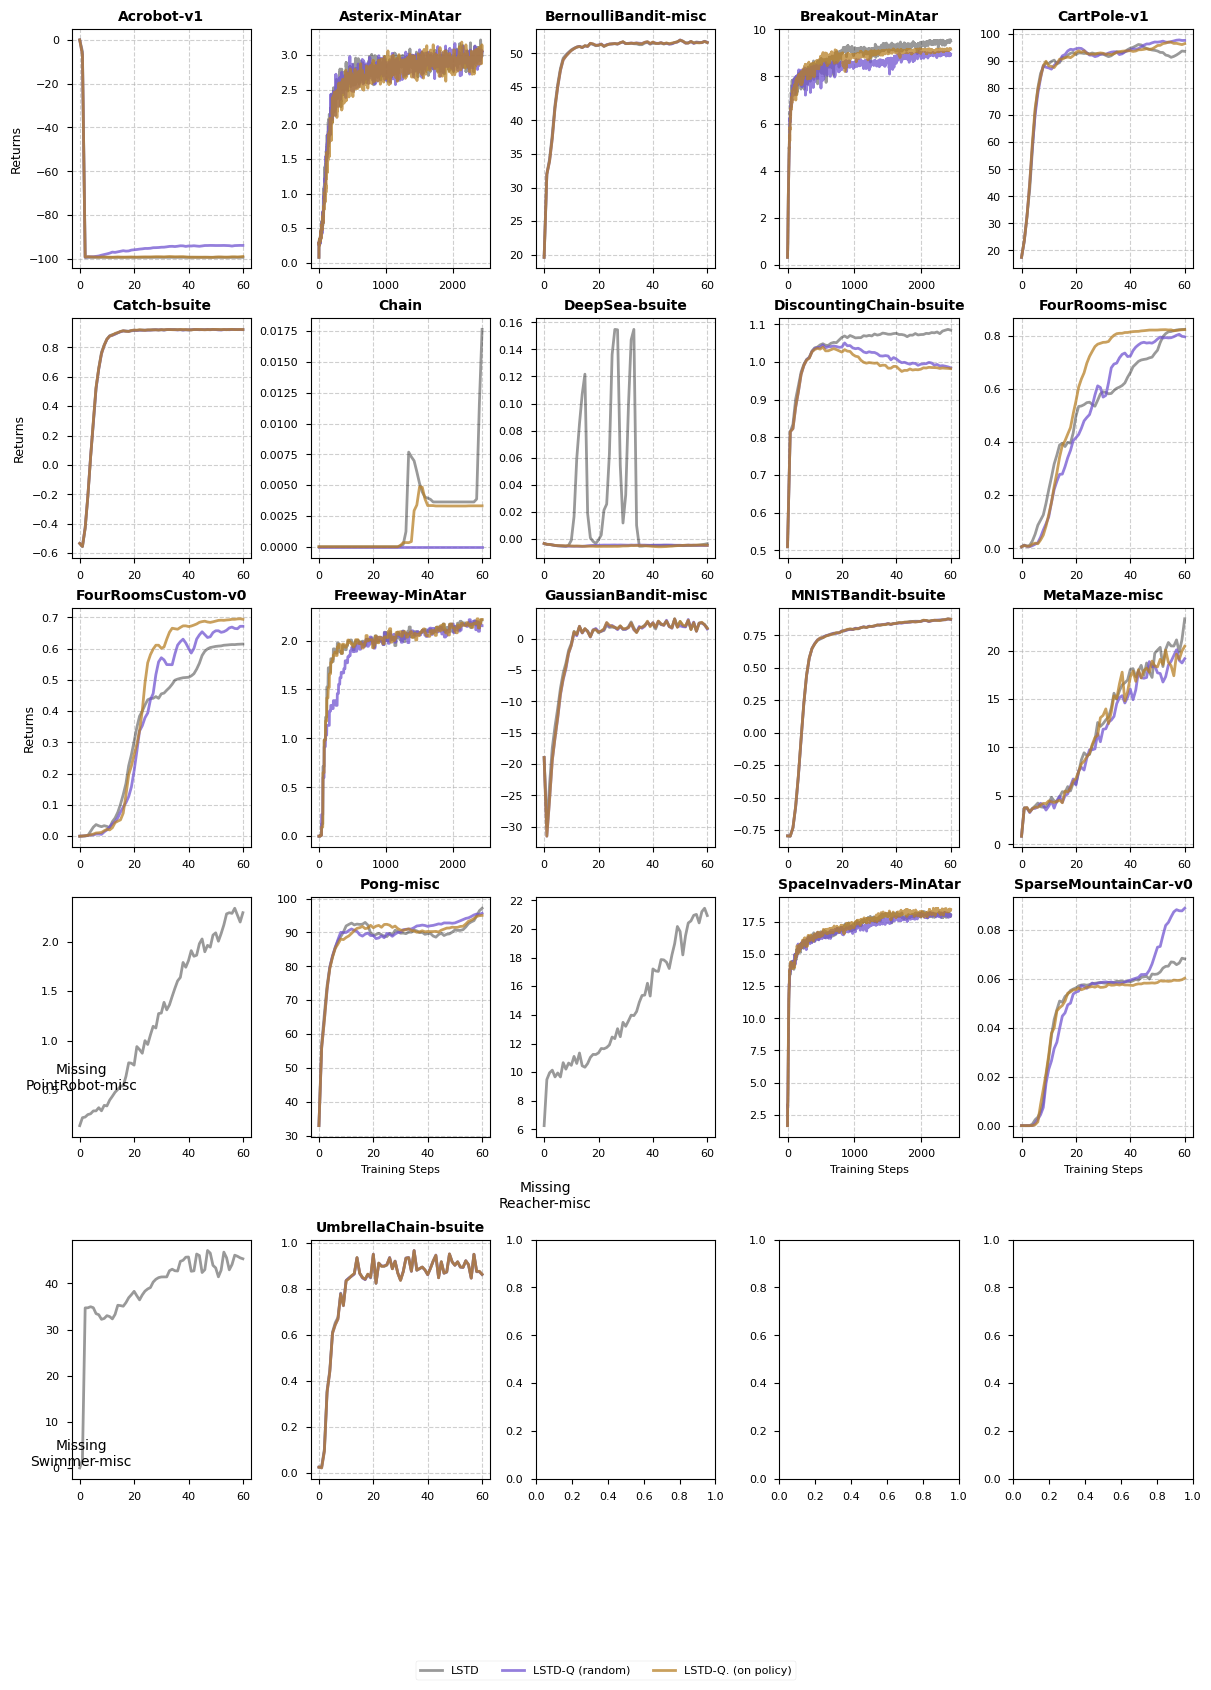

In [14]:
runs = [
    {"run_dir": "3_18_cov_lstd/ep_2", "name": "LSTD", "color": "black", "alpha": 0.4},
    # {"run_dir": "3_23_cov_lspi/ep", "name": "LSPI", "color": "#1f77b4", "alpha": 0.75},
    {"run_dir": "3_23_cov_lstd_q/ep_opt_init", "name": "LSTD-Q (random)", "color": "#7154d1", "alpha": 0.75},
    {"run_dir": "3_23_cov_lstd_q_on_policy/ep_opt_init", "name": "LSTD-Q. (on policy)", "color": "#b88027", "alpha": 0.75},
]

plot_all(runs)

Error loading PointRobot-misc: [Errno 2] No such file or directory: '../results/3_23_cov_lstd_q/cont_opt_init/PointRobot-misc/config.json'
Error loading Reacher-misc: [Errno 2] No such file or directory: '../results/3_23_cov_lstd_q/cont_opt_init/Reacher-misc/config.json'
Error loading Swimmer-misc: [Errno 2] No such file or directory: '../results/3_23_cov_lstd_q/cont_opt_init/Swimmer-misc/config.json'


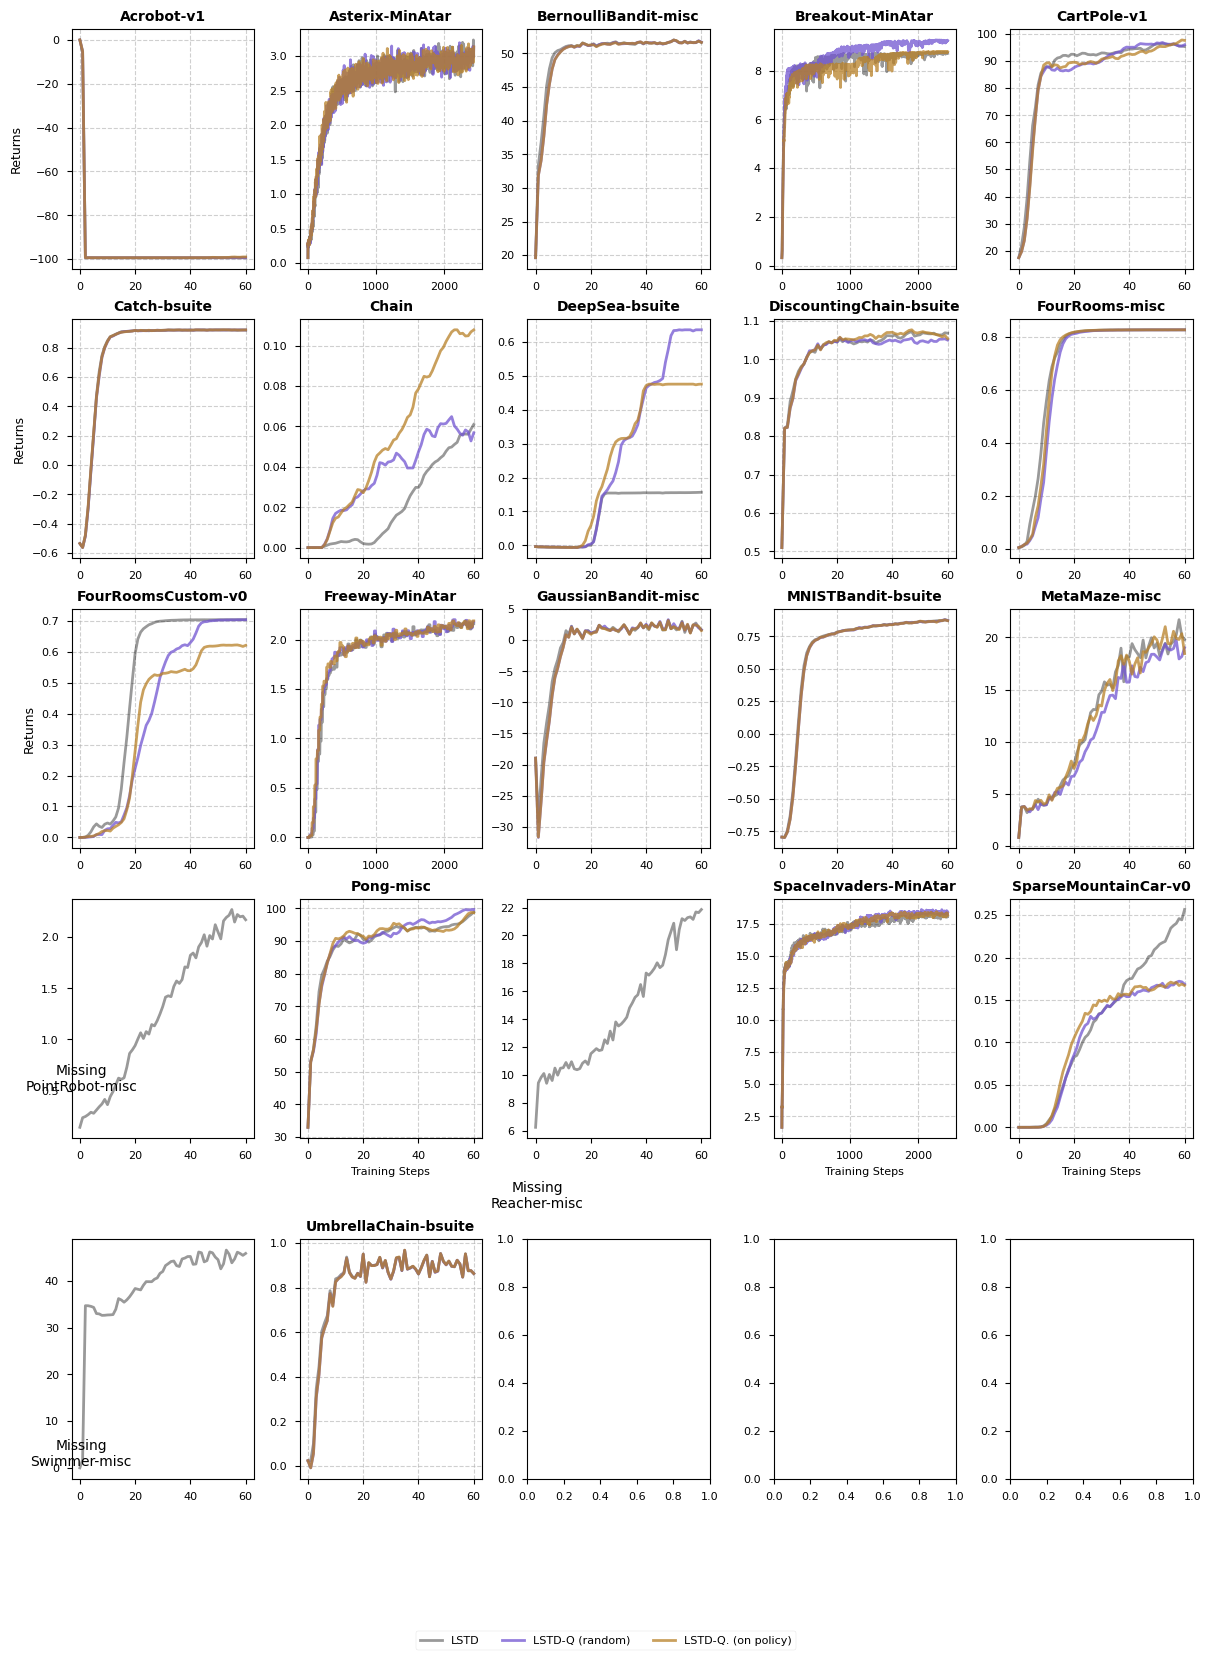

In [11]:
runs = [
    {"run_dir": "3_18_cov_lstd/cont_2", "name": "LSTD", "color": "black", "alpha": 0.4},
    # {"run_dir": "3_23_cov_lspi/ep", "name": "LSPI", "color": "#1f77b4", "alpha": 0.75},
    {"run_dir": "3_23_cov_lstd_q/cont_opt_init", "name": "LSTD-Q (random)", "color": "#7154d1", "alpha": 0.75},
    {"run_dir": "3_23_cov_lstd_q_on_policy/cont_opt_init", "name": "LSTD-Q. (on policy)", "color": "#b88027", "alpha": 0.75},
]

plot_all(runs)

Error loading PointRobot-misc: [Errno 2] No such file or directory: '../results/3_23_cov_lstd_q/cont/PointRobot-misc/config.json'
Error loading Reacher-misc: [Errno 2] No such file or directory: '../results/3_23_cov_lstd_q/cont/Reacher-misc/config.json'
Error loading Swimmer-misc: [Errno 2] No such file or directory: '../results/3_23_cov_lstd_q/cont/Swimmer-misc/config.json'


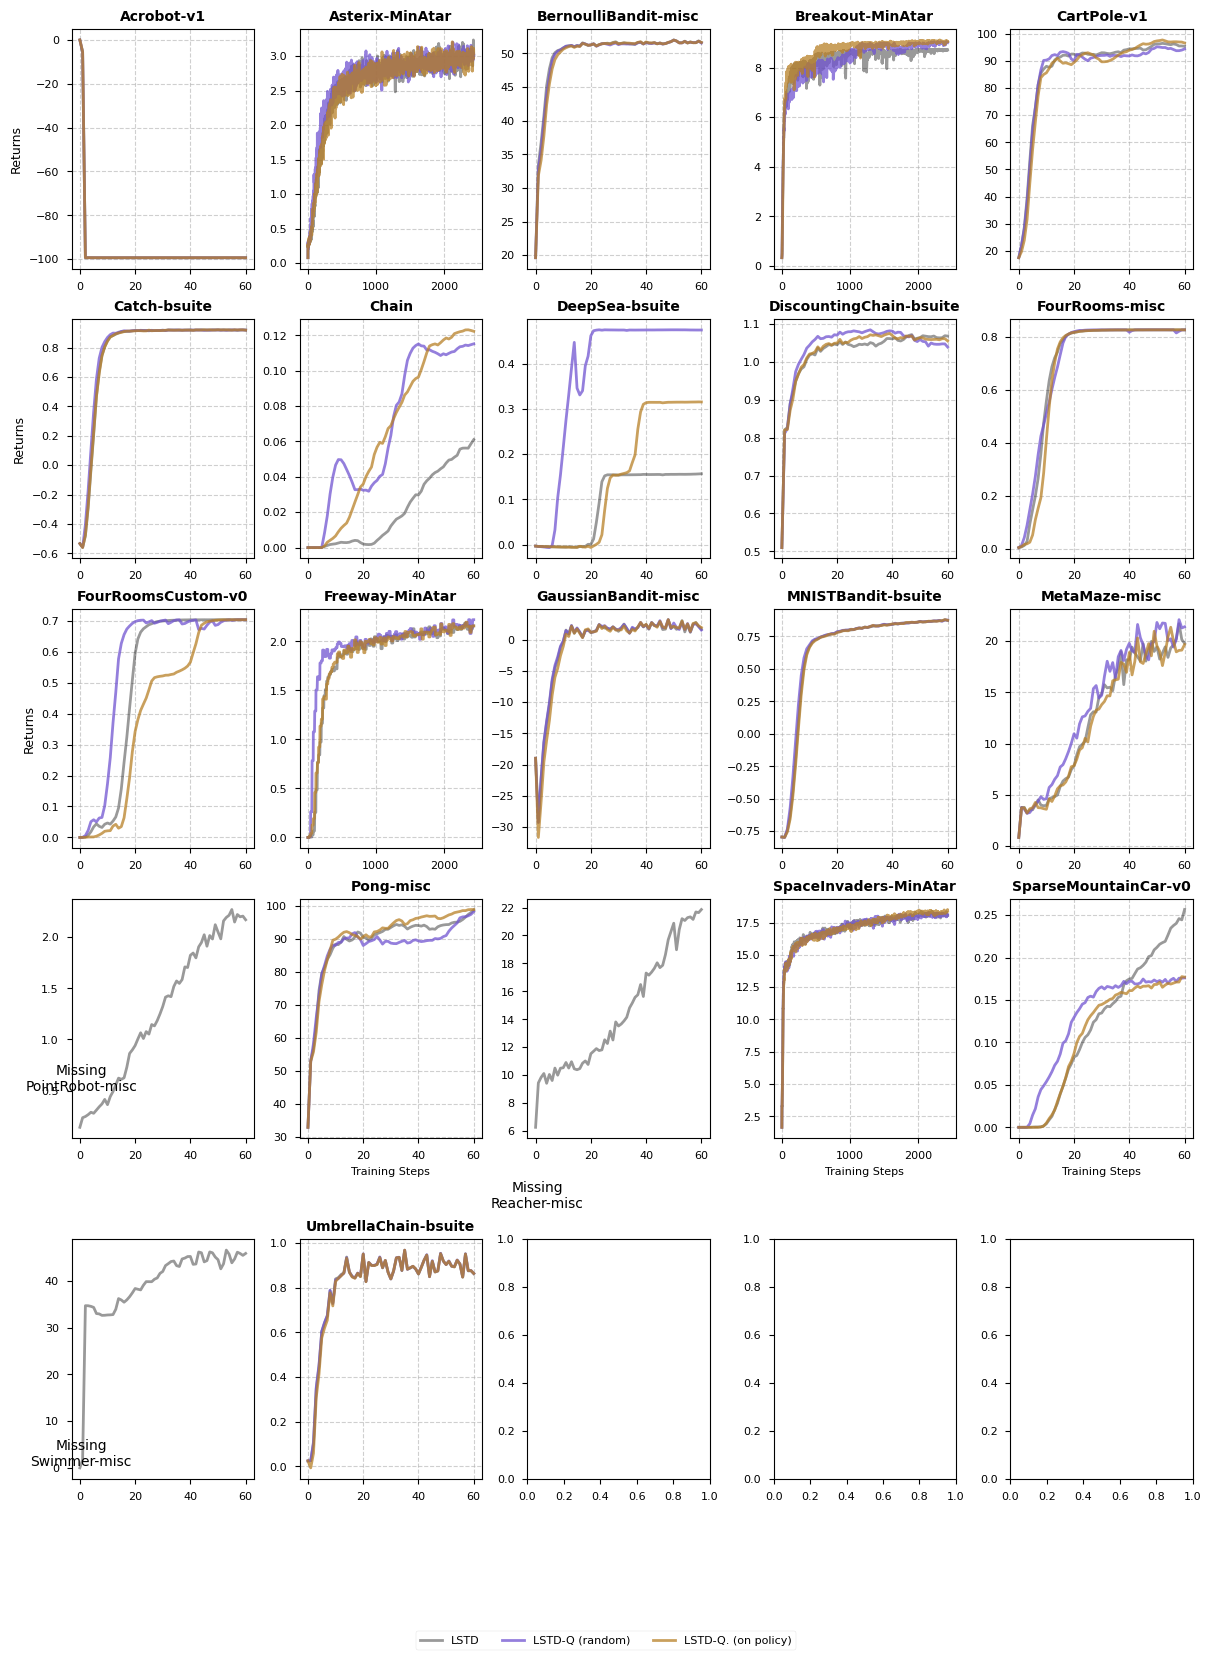

In [12]:
runs = [
    {"run_dir": "3_18_cov_lstd/cont_2", "name": "LSTD", "color": "black", "alpha": 0.4},
    # {"run_dir": "3_23_cov_lspi/ep", "name": "LSPI", "color": "#1f77b4", "alpha": 0.75},
    {"run_dir": "3_23_cov_lstd_q/cont", "name": "LSTD-Q (random)", "color": "#7154d1", "alpha": 0.75},
    {"run_dir": "3_23_cov_lstd_q_on_policy/cont", "name": "LSTD-Q. (on policy)", "color": "#b88027", "alpha": 0.75},
]

plot_all(runs)

[CpuDevice(id=0)]


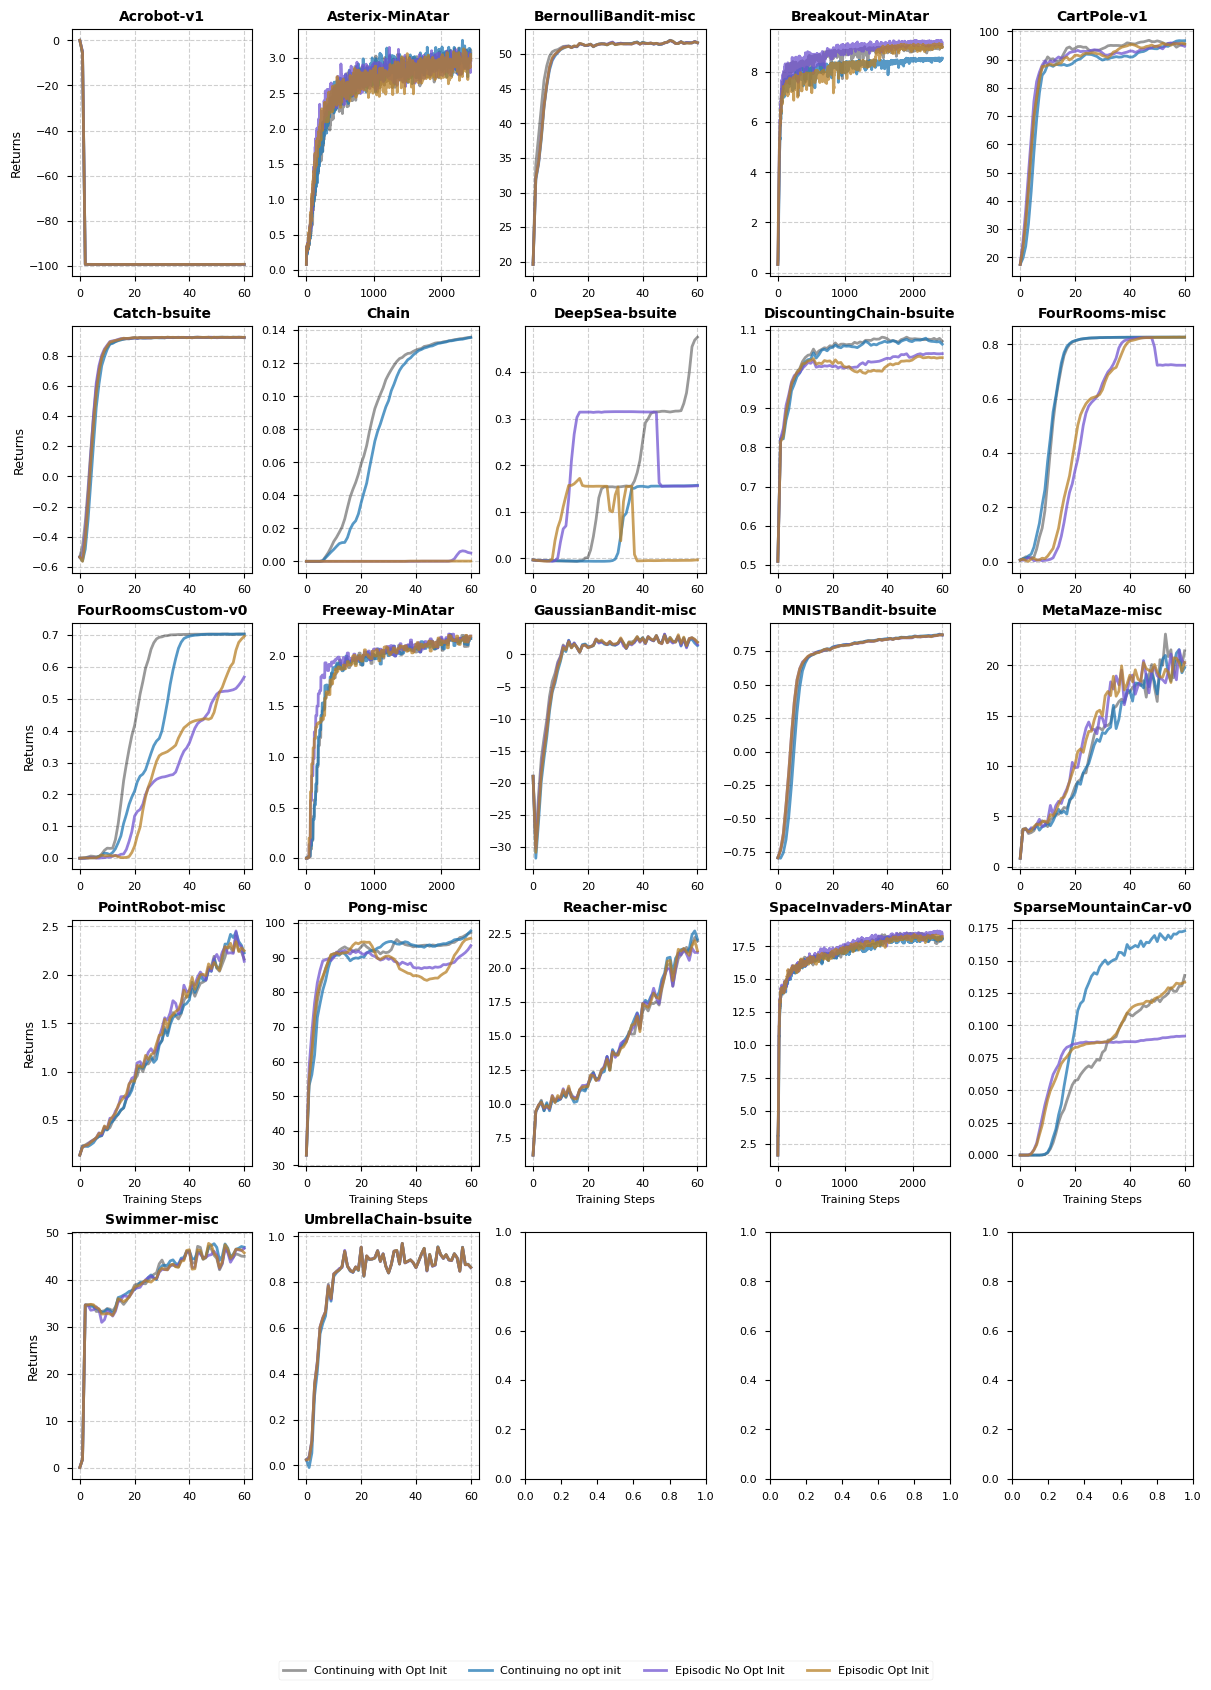

In [ ]:
# comparision of Episodic / Continuing and Optimism vs No Optimism
# --- Define runs once ---
RUNS = [
    {"run_dir": "3_13_cov_lstd/cont_opt_init", "name": "Continuing with Opt Init", "color": "black", "alpha": 0.4},
    {"run_dir": "3_13_cov_lstd/cont_no_opt_init", "name": "Continuing no opt init", "color": "#1f77b4", "alpha": 0.75},
    {"run_dir": "3_13_cov_lstd/ep_no_opt_init", "name": "Episodic No Opt Init", "color": "#7154d1", "alpha": 0.75},
    {"run_dir": "3_13_cov_lstd/ep_opt_init", "name": "Episodic Opt Init", "color": "#b88027", "alpha": 0.75},
]
plot_all(RUNS)

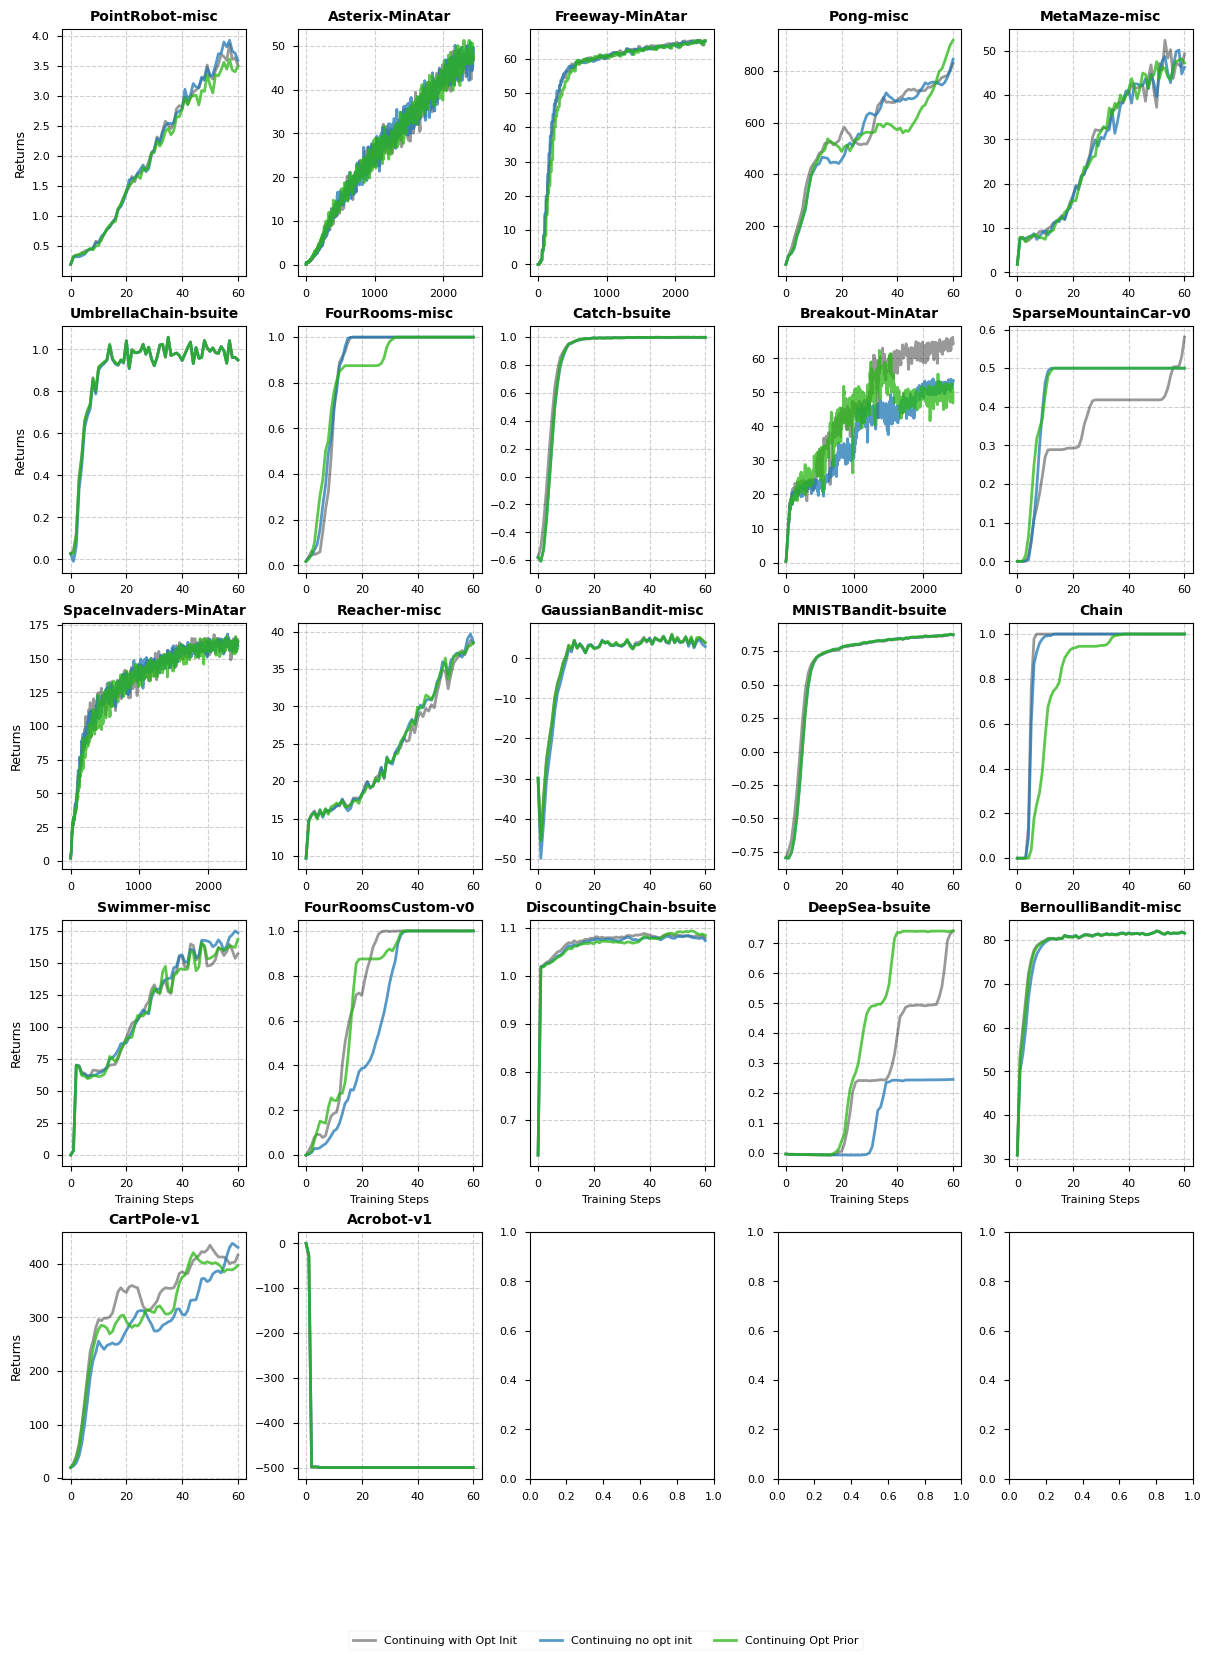

In [6]:


# --- Define runs once ---
RUNS = [
    {"run_dir": "3_13_cov_lstd/cont_opt_init", "name": "Continuing with Opt Init", "color": "black", "alpha": 0.4},
    {"run_dir": "3_13_cov_lstd/cont_no_opt_init", "name": "Continuing no opt init", "color": "#1f77b4", "alpha": 0.75},
    # {"run_dir": "3_13_cov_lstd/ep_no_opt_init", "name": "Episodic No Opt Init", "color": "#7154d1", "alpha": 0.75},
    # {"run_dir": "3_13_cov_lstd/ep_opt_init", "name": "Episodic Opt Init", "color": "#b88027", "alpha": 0.75},
    # {"run_dir": "3_18_cov_lstd/ep", "name": "Episodic Opt Prior", "color": "#b82750", "alpha": 0.75},
    {"run_dir": "3_18_cov_lstd/cont", "name": "Continuing Opt Prior", "color": "#28b612", "alpha": 0.75},
]

envs = set()
for k in CONFIG_REGISTRY:
    envs = envs.union(set(CONFIG_REGISTRY[k]['envs']))


plt.style.use('seaborn-v0_8-paper')
n_rows = 5
n_cols = 5
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*3, 5*3), constrained_layout=True)
axes = axes.flatten()

handles, labels = [], []

for i, ENV in enumerate(envs):
    ax = axes[i]

    try:
        for run in RUNS:
            config, metrics = load_run_data(run["run_dir"], ENV)

            # Average across seeds if needed
            if run["name"] == "PPO":
                metrics_avg = jax.tree.map(lambda x: x.mean(0), metrics)
                rets = metrics_avg['returned_episode_returns']
            else:
                rets = metrics['returned_episode_returns'].mean(0)

            line, = ax.plot(
                rets,
                label=run["name"],
                color=run.get("color", None),
                alpha=run.get("alpha", 1.0),
                linewidth=2,
            )

            # Save legend handles once
            if i == 0:
                handles.append(line)
                labels.append(run["name"])

        # --- Formatting ---
        ax.set_title(ENV, fontweight='bold', fontsize=10)

        row = i // n_cols
        col = i % n_rows

        # X labels only on bottom row
        if row == 3:
            ax.set_xlabel('Training Steps', fontsize=8)
        else:
            ax.set_xlabel('')

        # Y labels only on left column
        if col == 0:
            ax.set_ylabel('Returns', fontsize=9)
        else:
            ax.set_ylabel('')

        ax.grid(True, linestyle='--', alpha=0.6)

    except Exception as e:
        ax.text(0.5, 0.5, f"Missing\n{ENV}", ha='center')
        print(f"Error loading {ENV}: {e}")

# --- Shared legend ---
fig.legend(
    handles, labels,
    loc='lower center',
    ncol=len(RUNS),
    bbox_to_anchor=(0.5, -0.1),
    frameon=True,
    fontsize=8
)

plt.show()


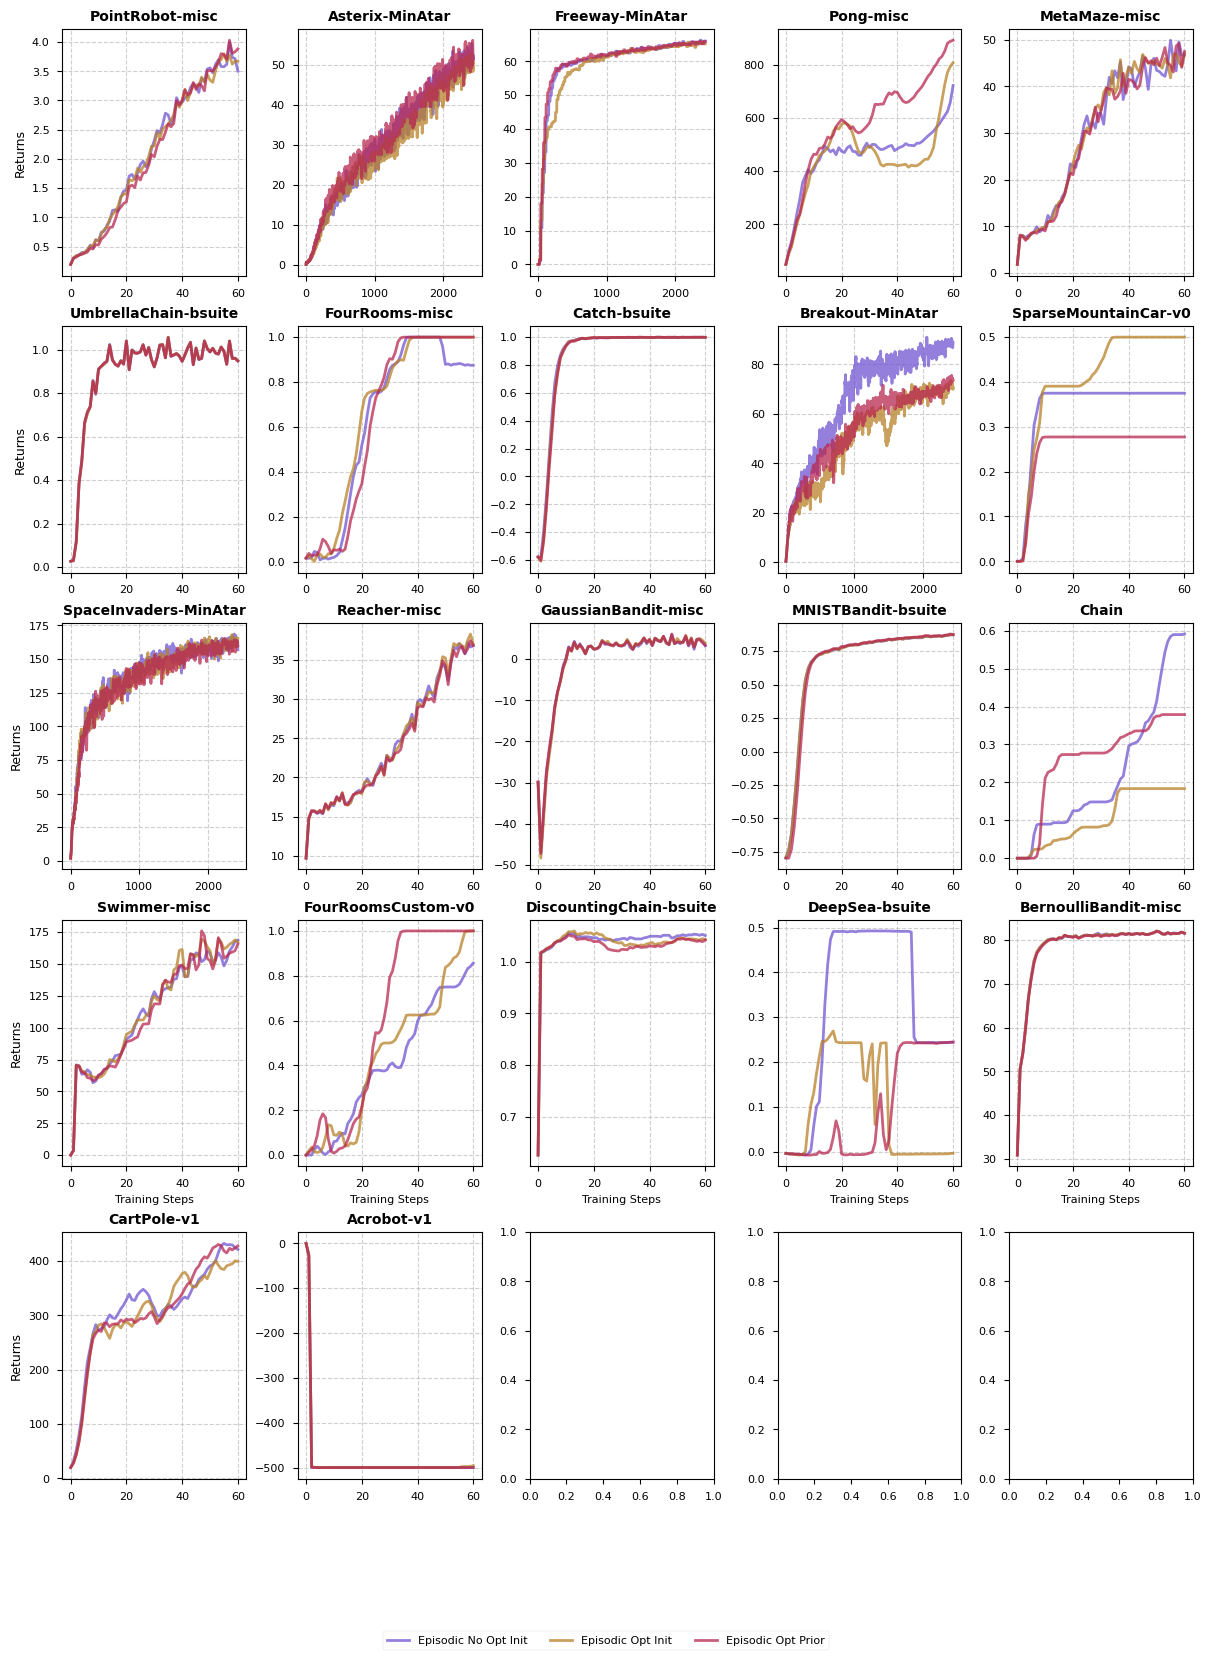

In [7]:
RUNS = [
    # {"run_dir": "3_13_cov_lstd/cont_opt_init", "name": "Continuing with Opt Init", "color": "black", "alpha": 0.4},
    # {"run_dir": "3_13_cov_lstd/cont_no_opt_init", "name": "Continuing no opt init", "color": "#1f77b4", "alpha": 0.75},
    {"run_dir": "3_13_cov_lstd/ep_no_opt_init", "name": "Episodic No Opt Init", "color": "#7154d1", "alpha": 0.75},
    {"run_dir": "3_13_cov_lstd/ep_opt_init", "name": "Episodic Opt Init", "color": "#b88027", "alpha": 0.75},
    {"run_dir": "3_18_cov_lstd/ep", "name": "Episodic Opt Prior", "color": "#b82750", "alpha": 0.75},
    # {"run_dir": "3_18_cov_lstd/cont", "name": "Continuing Opt Prior", "color": "#28b612", "alpha": 0.75},
]


envs = set()
for k in CONFIG_REGISTRY:
    envs = envs.union(set(CONFIG_REGISTRY[k]['envs']))


plt.style.use('seaborn-v0_8-paper')
n_rows = 5
n_cols = 5
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*3, 5*3), constrained_layout=True)
axes = axes.flatten()

handles, labels = [], []

for i, ENV in enumerate(envs):
    ax = axes[i]

    try:
        for run in RUNS:
            config, metrics = load_run_data(run["run_dir"], ENV)

            # Average across seeds if needed
            if run["name"] == "PPO":
                metrics_avg = jax.tree.map(lambda x: x.mean(0), metrics)
                rets = metrics_avg['returned_episode_returns']
            else:
                rets = metrics['returned_episode_returns'].mean(0)

            line, = ax.plot(
                rets,
                label=run["name"],
                color=run.get("color", None),
                alpha=run.get("alpha", 1.0),
                linewidth=2,
            )

            # Save legend handles once
            if i == 0:
                handles.append(line)
                labels.append(run["name"])

        # --- Formatting ---
        ax.set_title(ENV, fontweight='bold', fontsize=10)

        row = i // n_cols
        col = i % n_rows

        # X labels only on bottom row
        if row == 3:
            ax.set_xlabel('Training Steps', fontsize=8)
        else:
            ax.set_xlabel('')

        # Y labels only on left column
        if col == 0:
            ax.set_ylabel('Returns', fontsize=9)
        else:
            ax.set_ylabel('')

        ax.grid(True, linestyle='--', alpha=0.6)

    except Exception as e:
        ax.text(0.5, 0.5, f"Missing\n{ENV}", ha='center')
        print(f"Error loading {ENV}: {e}")

# --- Shared legend ---
fig.legend(
    handles, labels,
    loc='lower center',
    ncol=len(RUNS),
    bbox_to_anchor=(0.5, -0.1),
    frameon=True,
    fontsize=8
)

plt.show()
